In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import optax
import matplotlib.pyplot as plt
import diffrax
from tqdm.notebook import tqdm
import random
import numpy as np

In [4]:
spirals = jnp.load("spirals_100.npz")

print(spirals.files)

data_train = spirals["data_train"] # (10000, 100, 2)
data_val = spirals["data_validation"] # (10000, 100, 2)
data_test = spirals["data_test"] # (10000, 100, 2)

alpha_train = spirals["alpha_train"] # (10000, 1)
alpha_validation = spirals["alpha_validation"] # (10000, 1)

data_mean = jnp.mean(data_train, axis=(0, 1), keepdims=True)
data_std = jnp.std(data_train, axis=(0, 1), keepdims=True)

alpha_mean = jnp.mean(alpha_train)
alpha_std = jnp.std(alpha_train)

['data_train', 'alpha_train', 'data_validation', 'alpha_validation', 'data_test']


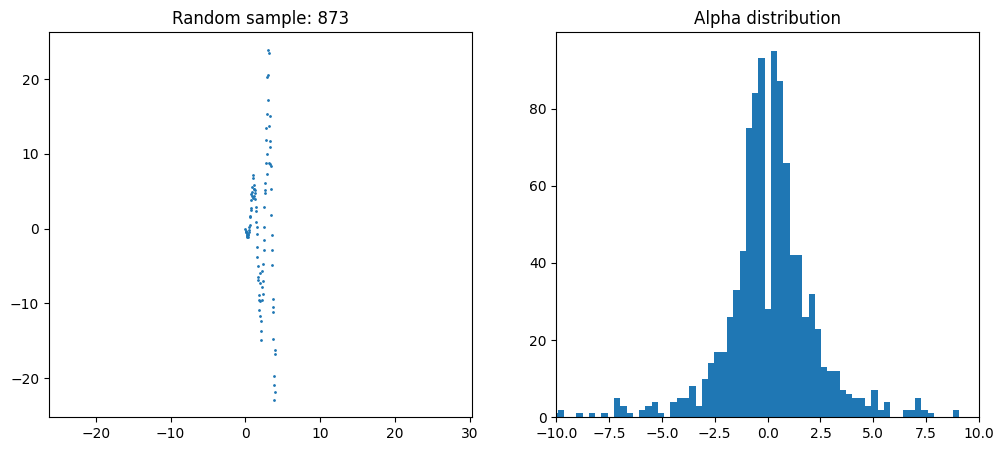

In [5]:
# data verification
rand_idx = random.randint(0, data_train.shape[0] - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter of a random training sample
axes[0].scatter(data_train[rand_idx, :, 0].flatten(), data_train[rand_idx, :, 1].flatten(), s=1)
axes[0].set_title(f"Random sample: {rand_idx}")
axes[0].axis("equal")

# alpha distribution
axes[1].hist(alpha_train.flatten(), bins=100)
axes[1].set_xlim(-10, 10)
axes[1].set_title("Alpha distribution")
plt.show()